# 📊 Визуализация EDA по датасету от Т-банка  
## для создания рекомендательной системы товаров маркетплейса

---

In [ ]:
!pip install polars

Датасет очень объемный (10 гб), поэтому библиотека pandas для анализа данных тут не подойдет. Берем библиотеку polars.

Импортирую polars и прочие стандартные библиотеки для работы с графиками и файловой системой.

In [4]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import os

In [ ]:
events_marketplace_path = '/content/drive/MyDrive/T-ECD-dataset/small/dataset/small/marketplace/events'
all_marketplace_events = sorted(glob.glob(os.path.join(events_marketplace_path, "*.pq")))

Так как файлы действий пользователей разбиты по дням, считываю все, добавляю столбец "day" и объединяю в один большой датафрейм.

In [ ]:
events_list = []
for file in all_marketplace_events:
    df_temp = pl.read_parquet(file)
    day = os.path.basename(file).replace('.pq', '')
    df_temp = df_temp.with_columns(pl.lit(day).alias('day'))
    events_list.append(df_temp)

marketplace_events_df = pl.concat(events_list)
print(marketplace_events_df.sample(10))
print(marketplace_events_df.shape)

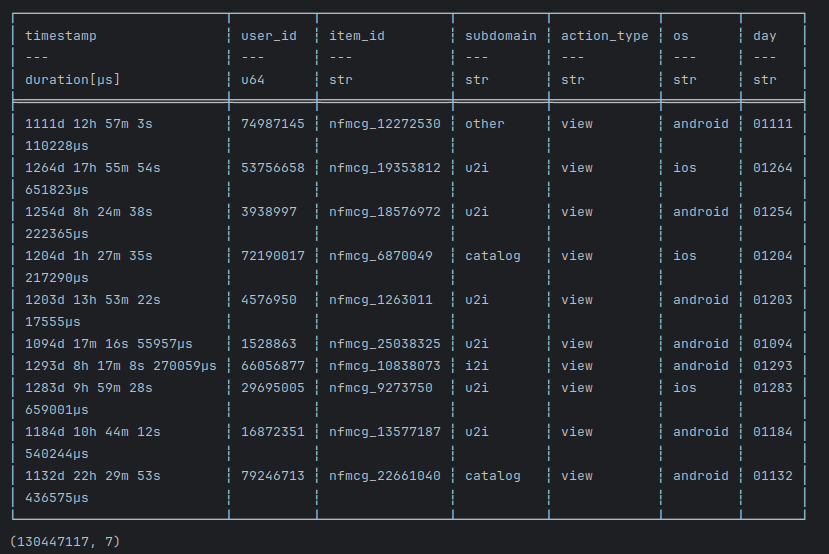

К сожалению в Google Collab не хватает оперативной памяти для выполнения процесса, поэтому прикрепляю скрины из локального терминала в PyCharm.

Видим 130,5 млн записей о действиях пользователей на маркетплейсе.

Имеем столбцы: временная отметка, user_id, item_it, место на сайте где было действие, тип действия (просмотр, кликаут, лайк и клик), ОС (Android, IOS).

# 📊 Построим стобчатую диаграмму распределения типов действий.

In [ ]:
plt.figure(figsize=(12, 6))
action_counts = (marketplace_events_df.group_by("action_type").len().sort("len", descending=True))
action_counts_pd = action_counts.to_pandas() #создаю пандас дата фрейм для работы с matplotlib

action_counts_pd.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.8)
plt.title('Распределение типов действий пользователей marketplace')
plt.xlabel('Тип действия', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') #отключаю научное преобразование чисел
plt.xticks(ticks=range(len(action_counts_pd["action_type"])),labels=action_counts_pd["action_type"], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend().remove()
max_count = action_counts_pd["len"].max()
for i, count in enumerate(action_counts_pd["len"]):
    plt.text(i, count + max_count * 0.01, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show() #сохраняю графики локально, так как в коллабе не хватает памяти.

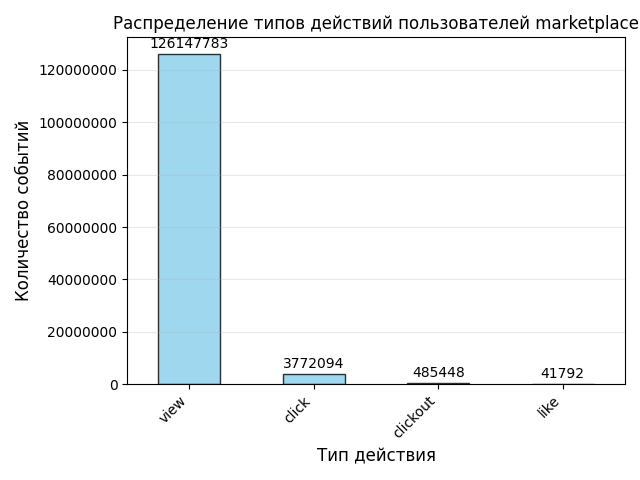

Сразу видна очень низкая конверсия в целевые действия. Предполагаем, что clickout - это переход на сторонние партнерские ресурсы из рекламных баннеров, нас эта фича не очень интересует. Целевые для нас действия - это click и like. Получается понятная воронка: просмотр -> клик -> лайн (добавление в избранное). Удалю действия с clickout из датасета.

In [ ]:
marketplace_events_df = marketplace_events_df.filter(pl.col("action_type") != "clickout")
print(marketplace_events_df.select("action_type").unique()) #смотрим, какие уникальные значения остались в столбце.

# 📊 Построим столбчатую диаграмму распределения действий по субдоменам.

In [ ]:
plt.figure(figsize=(12, 6))
action_counts = (marketplace_events_df.group_by("subdomain").len().sort("len", descending=True))
action_counts_pd = action_counts.to_pandas()
action_counts_pd.plot(kind='bar', color='yellow', edgecolor='black', alpha=0.8)
plt.title('Распределение типов действий пользователей в subdomains')
plt.xlabel('Subdomain', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') #отключаю научное преобразование чисел
plt.xticks(ticks=range(len(action_counts_pd["subdomain"])),labels=action_counts_pd["subdomain"], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend().remove()
max_count = action_counts_pd["len"].max()
for i, count in enumerate(action_counts_pd["len"]):
    plt.text(i, count + max_count * 0.01, str(count), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

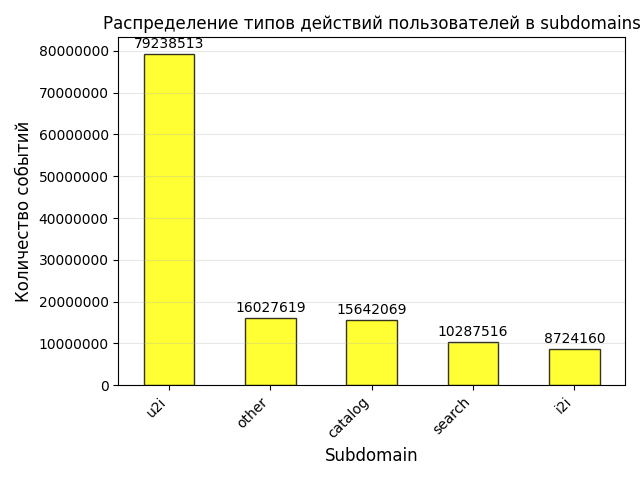

# 📊 Построим столбчатую диаграмму распределения действий по разным ОС

In [ ]:
plt.figure(figsize=(12, 6))
action_counts = (marketplace_events_df.group_by("os").len().sort("len", descending=True))
action_counts_pd = action_counts.to_pandas()
action_counts_pd.plot(kind='bar', color='blue', edgecolor='black', alpha=0.8)
plt.title('Распределение действий пользователей по разным ОС')
plt.xlabel('ОС', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') #отключаю научное преобразование чисел
plt.xticks(ticks=range(len(action_counts_pd["os"])),labels=action_counts_pd["os"], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend().remove()
max_count = action_counts_pd["len"].max()
for i, count in enumerate(action_counts_pd["len"]):
    plt.text(i, count + max_count * 0.01, str(count), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

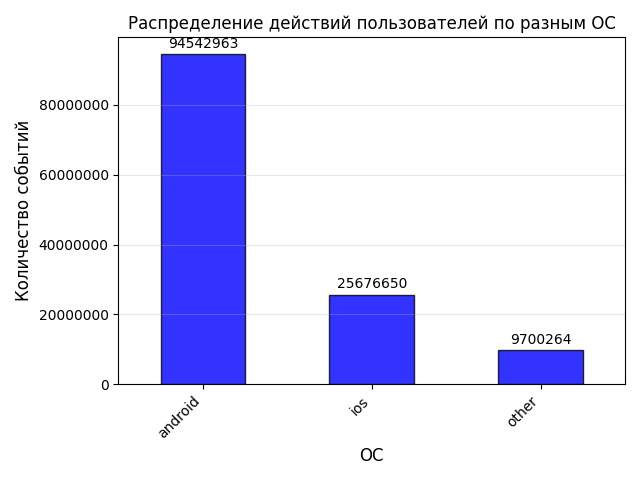

# 📊 Построим heatmap, чтоб увидеть активность действий пользователей на разных субдоменах.


In [ ]:
plt.figure(figsize=(12, 6))
action_subdomain = pd.crosstab(marketplace_events_df['action_type'], marketplace_events_df['subdomain'])
ax = sns.heatmap(action_subdomain, fmt='d', cmap='Reds', annot=True)
ax.set_ylabel('Действие пользователя', fontsize=12)
ax.set_xlabel('Место (subdomain)', fontsize=12)
plt.title('Тепловая карта Действие - Место в marketplace')
plt.tight_layout()
plt.show()

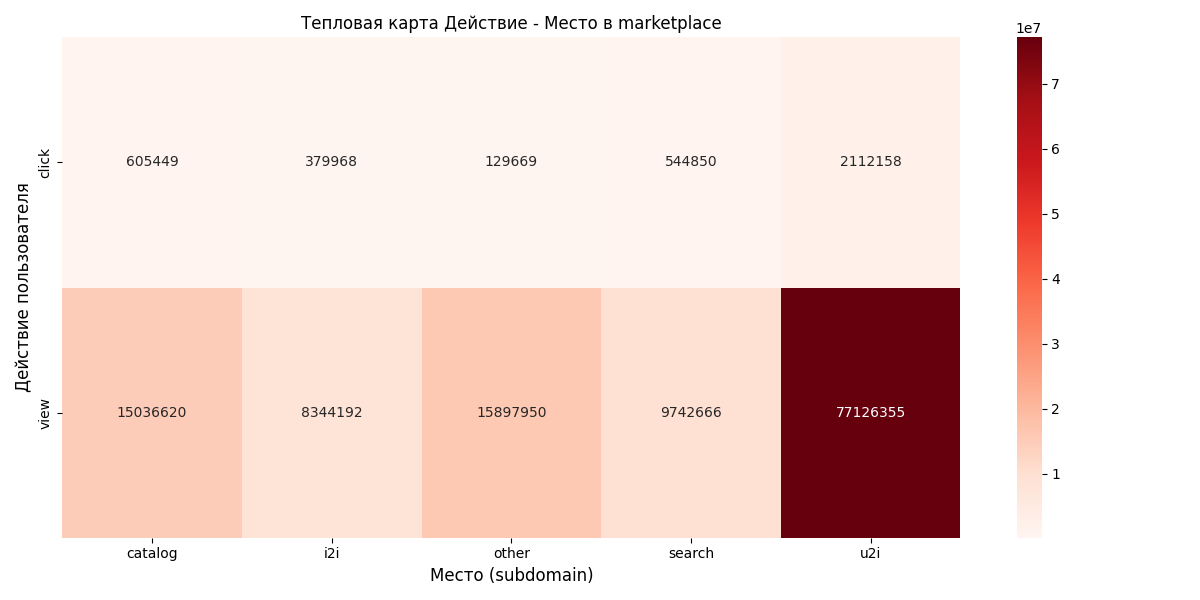

Мы видим, что лайк отсутствует на тепловой карте. Все дело в том, что у действия лайк отсутствует фича "subdomain". Это, скорее всего, связано с тем, что в избранное товар добавляют только из карточки после действия "click". В других местах сайта это невозможно. Также по тепловой карте мы видим, что больше всего просмотров товаров и кликов по ним приходится на ленту рекомендаций "u2i".

In [ ]:
unique_like_subdomains = marketplace_events_df.filter(pl.col("action_type") == "like").select("subdomain").unique()
print(unique_like_subdomains)

shape: (1, 1)
┌───────────┐
│ subdomain │
│ ---       │
│ str       │
╞═══════════╡
│ null      │
└───────────┘


# 📊 Построим столбчатые диаграммы конверсий из каждого этапа воронки. Из view в click и из click в like.

In [ ]:
action_counts = (marketplace_events_df.group_by("action_type").len().sort("len", descending=True))
action_counts_pd = action_counts.to_pandas()
click = action_counts_pd.loc[1, 'len']
like = action_counts_pd.loc[2, 'len']
conversion = pd.Series([round(click/action_counts_pd.loc[0, 'len'] * 100, 3), round(like/click * 100, 3)], index=['click', 'like'])
plt.figure(figsize=(12, 6))
conversion.plot(kind='bar', color='red', edgecolor='black', alpha=0.8)
plt.title('Воронка конверсий из view в click и из click в like', fontsize=16, fontweight='bold')
plt.xlabel('Конверсия', fontsize=12)
plt.ylabel('Проценты', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
for i, count in enumerate(conversion):
    plt.text(i, count + max(conversion)*0.01, str(count),
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

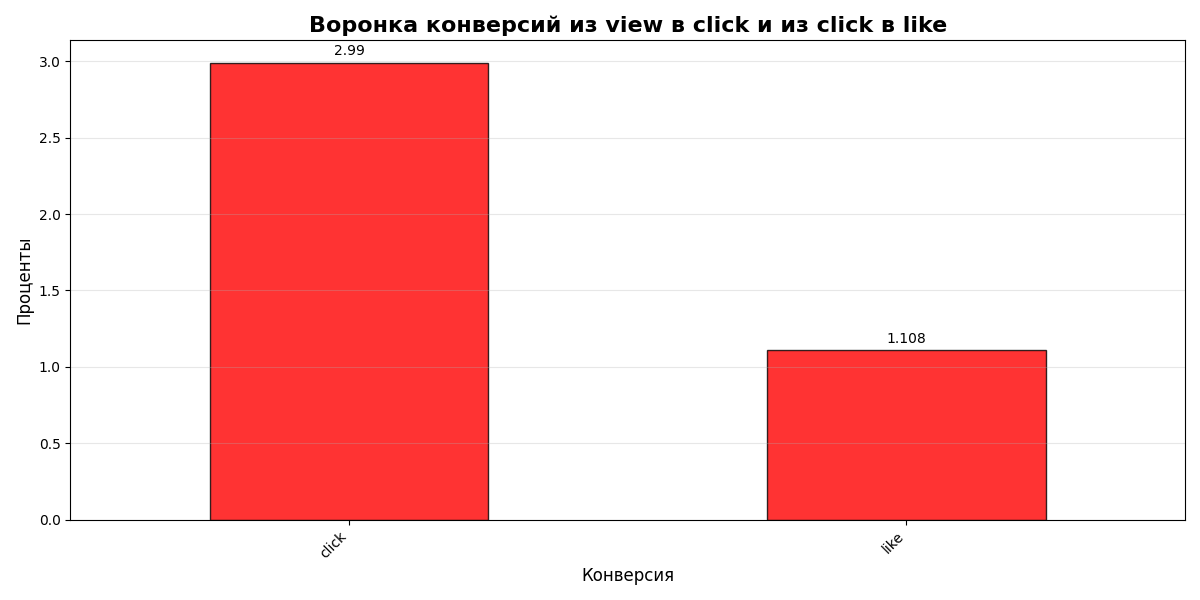

Мы видим довольно низкую конверсию на каждом этапе воронки. 3% на этапе из просмотров в клики и 1,1% из кликов в лайк. Общая конверсия в целевое действие из всех действий составляет всего: 0,03%.

# 📊 Добавлю график изменения общей целевой конверсии в лайк по дням в течение 227 дней.

In [ ]:
#строчка ниже сгенерирована в deepseek, так как пока не знаком с методами библиотеки polars, которая взята по необходимости
events_per_day = (marketplace_events_df.group_by(['day', 'action_type']).agg(pl.len().alias('count')).pivot(index='day', on='action_type', aggregate_function='first').fill_null(0))
#перевожу в пандас и строю график в более привычной манере
events_per_day_pd = events_per_day.to_pandas()
events_per_day_pd['conversion'] = events_per_day_pd['like'] / (events_per_day_pd['view'] + events_per_day_pd['click'] + events_per_day_pd['like']) * 100

print(events_per_day_pd.head(10)) #вывел посмотреть получившиеся столбцы, убедиться, что все в порядке перед построением графика
plt.figure(figsize=(12, 6))
plt.plot(events_per_day_pd.index, events_per_day_pd['conversion'], marker='o', linewidth=2, markersize=4, color='#2E8B57')
plt.xticks(rotation=45, ha='center', fontsize=8)  #Чтоб подписи дней вмещались делаю их под углом
plt.title('Изменение конверсии по дням marketplace', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('День', fontsize=12)
plt.ylabel('Конверсия (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

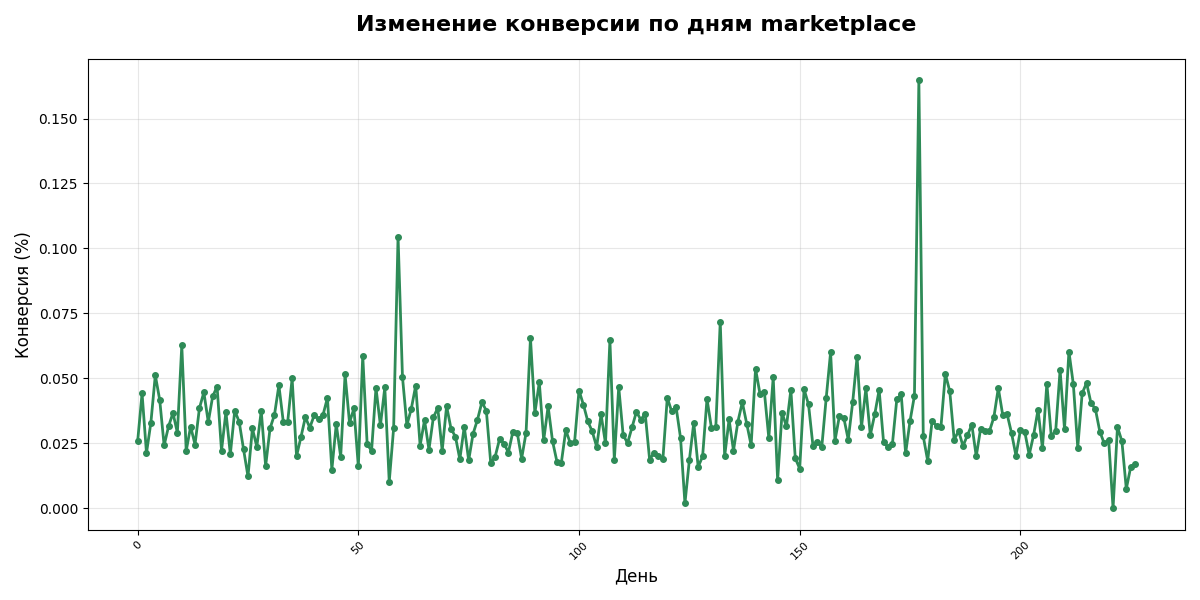

Конверсию в лайк, считаю, как долю действия лайк от всех действий.
Видно, что в среднем конверсия в лайк (избранное) колеблется около 0,03%, но есть пара явных выбросов, отличающихся в несколько раз от средних данных. Возможно, это связано с проведением каких-то массовых акций, вроде "Черной пятницы", когда люди быстрее принимают решение, меньше смотрят и больше действуют.

# 📊 Построим графики изменения ключевых действий по дням.

In [ ]:
#Построю график целевых действий по дням (клик и лайк)
key_events_per_day_pd = events_per_day_pd.drop(['view', 'conversion', 'day'], axis=1)
print(key_events_per_day_pd.mean())#выведу средние значения по дням

plt.figure(figsize=(12, 6))
plt.plot(key_events_per_day_pd.index, key_events_per_day_pd['click'], marker='o', linewidth=2, markersize=4)
plt.title('Динамика количества кликов по дням', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('День', fontsize=12)
plt.ylabel('Количество действий', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(key_events_per_day_pd.index, key_events_per_day_pd['like'], marker='o', linewidth=2, markersize=4)
plt.title('Динамика количества лайков по дням', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('День', fontsize=12)
plt.ylabel('Количество действий', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

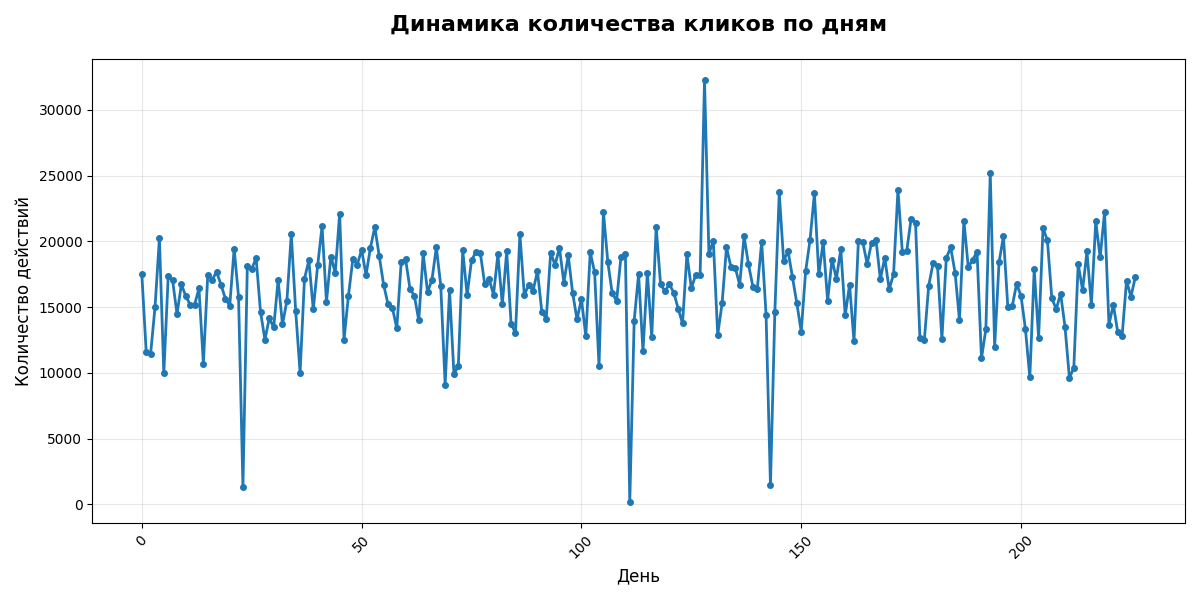

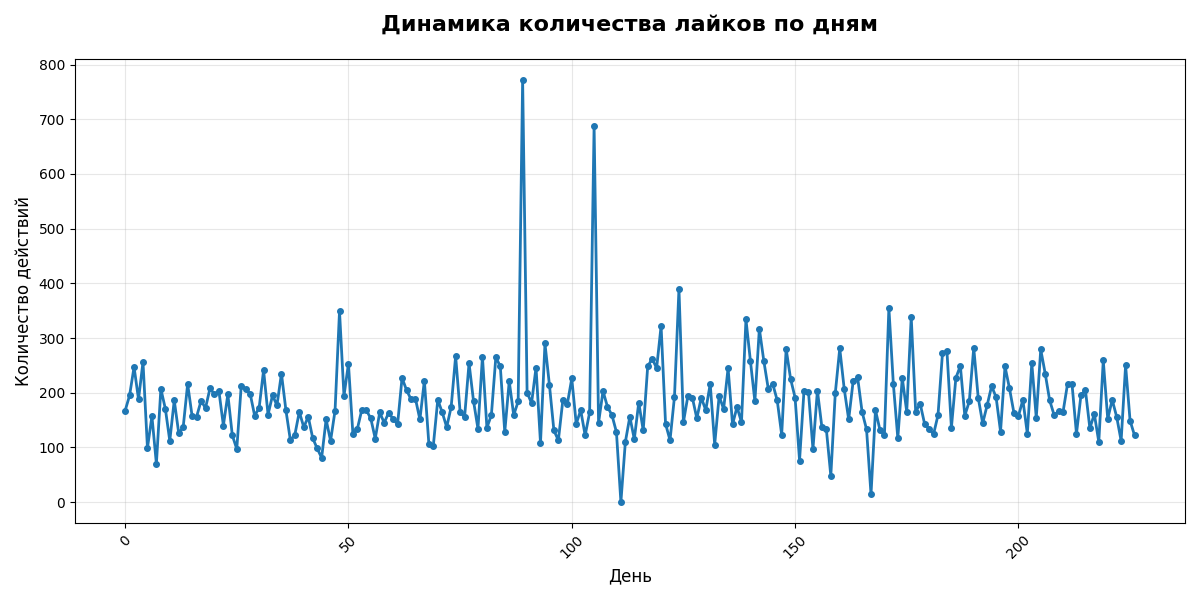

В среднем по дням 184 лайка и 16600 кликов. Из-за разных порядков разделил графики, чтоб лучше увидеть динамику. Видим несколько выбросов в обоих графиках. При этом дни пиковых значений на одном графике не всегда соответствуют пиковым значениям на другом. Так, например, на 143 день кликов было сильно меньше обычного, а лайков при этом чуть выше среднего.

# 📊 Рассмотрим количество действий по категориям.

Считываю файл товаров маркетплейса, используя библиотеку polars.

In [ ]:
items_marketplace = pl.read_parquet('/content/drive/MyDrive/T-ECD-dataset/small/dataset/small/marketplace/items.pq')
print(items_marketplace.shape)
print(items_marketplace.columns)

(2325409, 6)
['item_id', 'brand_id', 'category', 'subcategory', 'price', 'embedding']


In [ ]:
#перевожу таблицы товаров и действий в пандас для удобства дальнейшей работы.
items_marketplace_pd = items_marketplace.to_pandas()
marketplace_events_pd = marketplace_events_df.to_pandas()
#Объединяю события с товарами по item_id
merged_df = marketplace_events_pd.merge(items_marketplace_pd[['item_id', 'category']],on='item_id',how='left')
actions_by_category = merged_df.groupby('category').size().reset_index(name='actions_count')
actions_by_category = actions_by_category.sort_values('actions_count', ascending=False)
actions_by_category.set_index('actions_count')

plt.figure(figsize=(12, 8))
plt.bar(actions_by_category['category'], actions_by_category['actions_count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Категория')
plt.ylabel('Количество действий')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Действия по категориям Marketplace')
plt.tight_layout()
plt.savefig('/home/alex/PycharmProjects/tbankDataset/plots_polars/all_events_per_category.png')  # Сохраняем в файл
plt.close()

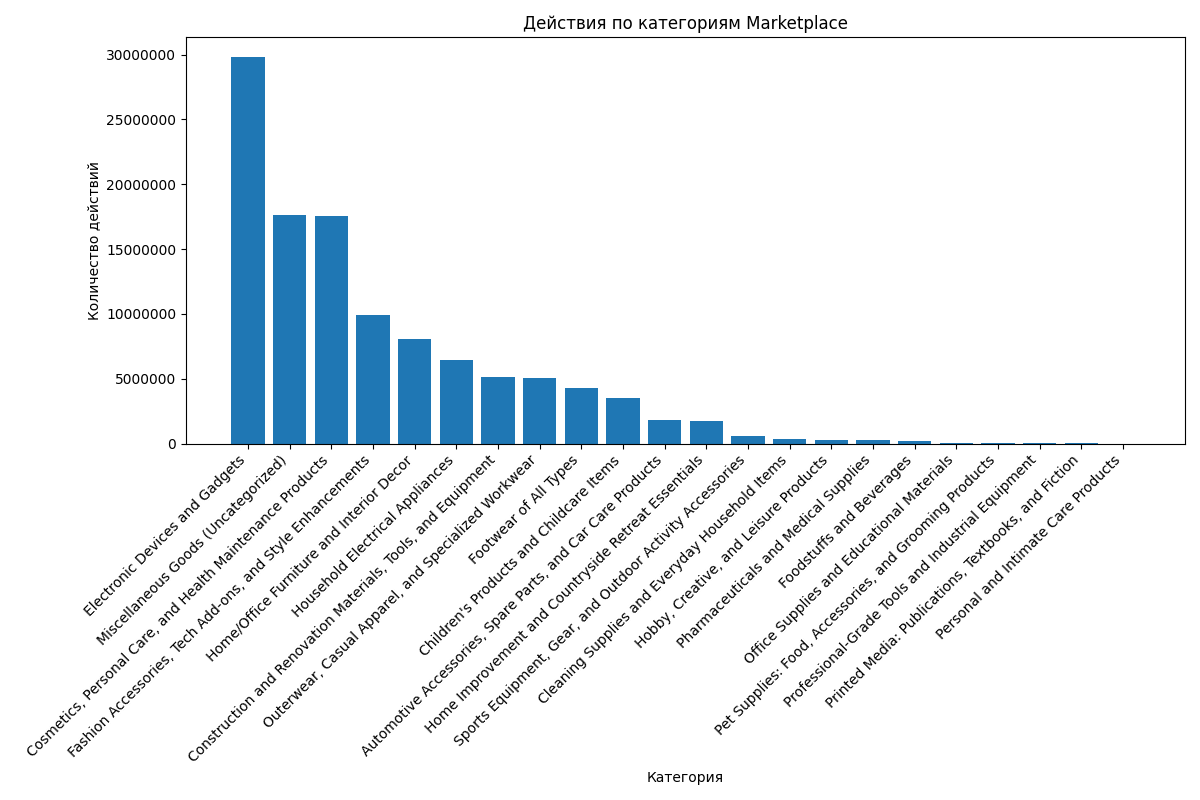

Мы видим, что явный лидер по популярности среди категорий товаров - это электроника. На втором и третьем месте примерно на одном уровне - прочие товары без категории и различная косметика.

# 📊 Теперь построим такой же график, но уже по ключевым действиям, будет ли изменение в топе категорий.

In [ ]:
#Строим графики по кликам и по лайкам в категориях
clicks_df = marketplace_events_pd[marketplace_events_pd['action_type'] == 'click']
clicks_merged = clicks_df.merge(items_marketplace_pd[['item_id', 'category']], on='item_id', how='left')
clicks_by_category = clicks_merged.groupby('category').size().reset_index(name='clicks_count')
clicks_by_category = clicks_by_category.sort_values('clicks_count', ascending=False)


likes_df = marketplace_events_pd[marketplace_events_pd['action_type'] == 'like']
likes_merged = likes_df.merge(items_marketplace_pd[['item_id', 'category']], on='item_id', how='left')
likes_by_category = likes_merged.groupby('category').size().reset_index(name='likes_count')
likes_by_category = likes_by_category.sort_values('likes_count', ascending=False)

#Строим график для кликов
plt.figure(figsize=(12, 8))
plt.bar(clicks_by_category['category'], clicks_by_category['clicks_count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Категория')
plt.ylabel('Количество кликов')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Клики по категориям Marketplace')
plt.tight_layout()
plt.show()

#Строим график для лайков
plt.figure(figsize=(12, 8))
plt.bar(likes_by_category['category'], likes_by_category['likes_count'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Категория')
plt.ylabel('Количество лайков')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Лайки по категориям Marketplace')
plt.tight_layout()
plt.show()


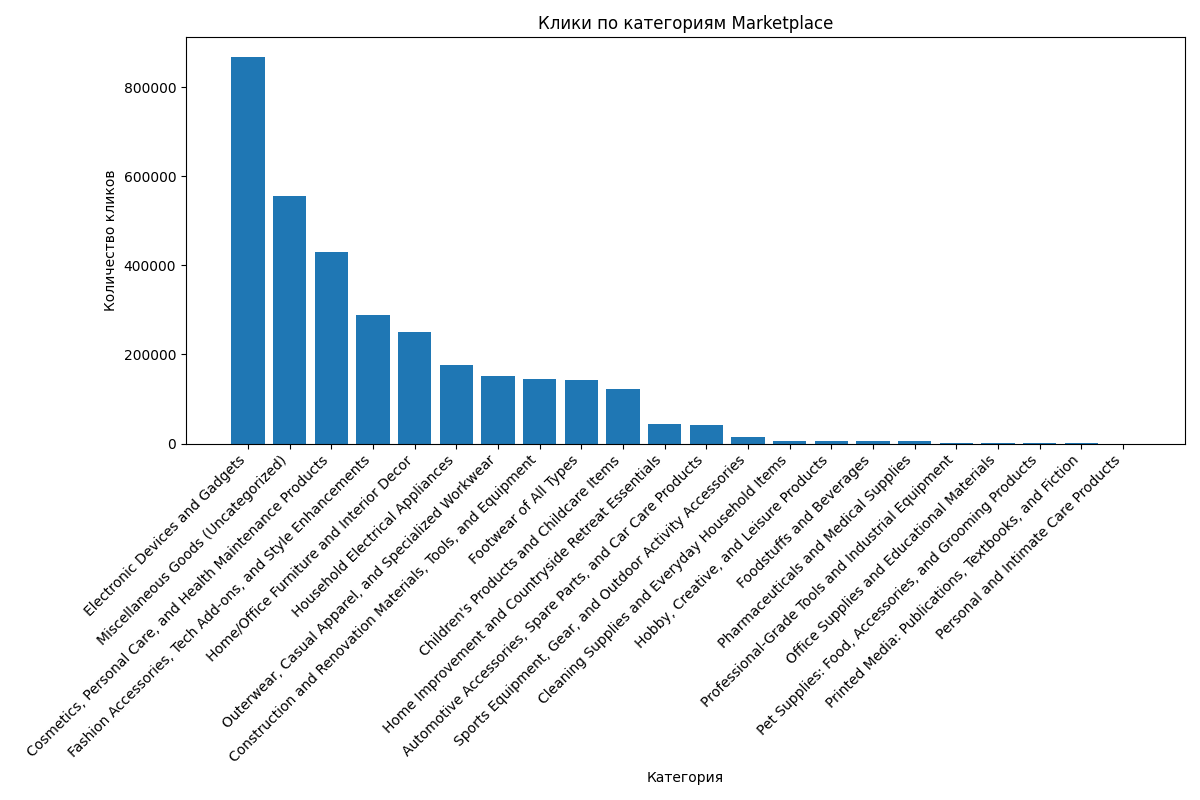

В случае с кликами мы видим изменения в столбчатой диаграмме по сравнению со всеми действиями в целом, но общий топ категорий остается неизменным.

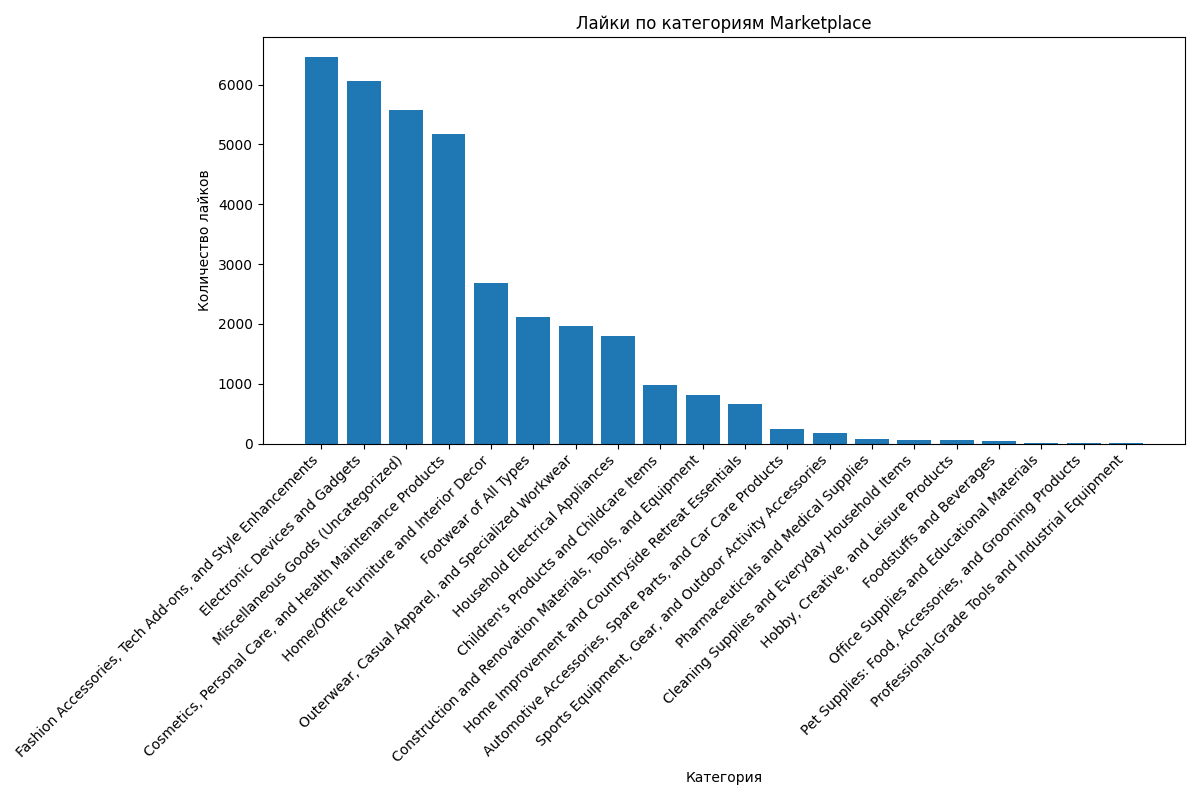

А вот в случае с лайками, ситуация меняется. Категория модных аксессуаров выходит на первое место по добавлению товаров в избранное (предположу, что в этой категории потребители склонны многие товары добавлять в избранное), на второе с небольшим отрывом сдвигается электроника, на третьем также прочие товары, а на четвертом косметика.

Теперь проделаю то же самое для конверсии в лайк по каждой категории. Посмотрим, какая категория наиболее "коневерсионная".

In [ ]:
actions_pivot = merged_df.pivot_table(index='category', columns='action_type', values='item_id', aggfunc='count', fill_value=0).reset_index()
actions_pivot['conversion_to_like'] = (actions_pivot['like'] / (actions_pivot['like'] + actions_pivot['view'] + actions_pivot['click'])) * 100
actions_pivot['conversion_to_like'] = actions_pivot['conversion_to_like'].replace([np.inf, -np.inf], 0).fillna(0) #заменяю бесконечные значения на ноль - строчку взял в deepseek
conversion_by_category = actions_pivot[['category', 'conversion_to_like']].sort_values('conversion_to_like', ascending=False)

plt.figure(figsize=(12, 8))
plt.bar(conversion_by_category['category'], conversion_by_category['conversion_to_like'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Категория')
plt.ylabel('Конверсия в лайк (%)')
plt.title('Конверсия в лайк по категориям Marketplace')
plt.tight_layout()
plt.savefig('/home/alex/PycharmProjects/tbankDataset/plots_polars/conversion_per_category.png')
plt.close()

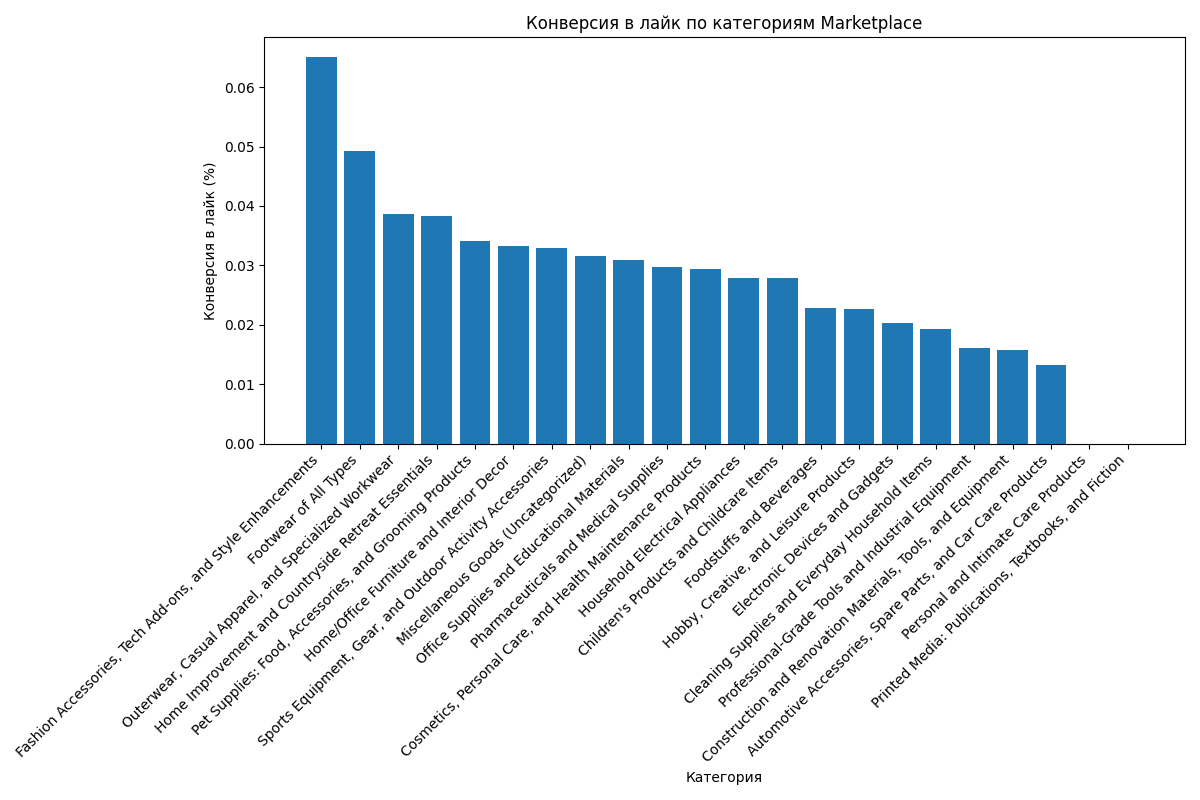

Топ самых конверсионных категорий: Аксессуары, Обувь, верхняя одежда. Электроника сдвинулась на 16-е место.

# 📊 Теперь построим heatmap действий по ТОП-20 категориям.

In [ ]:
pivot_table = pd.crosstab(index = merged_df['category'],columns = merged_df['action_type'])

#Беру топ 20 категорий
top_categories = actions_by_category.head(20)['category'].tolist()
pivot_table_filtered = pivot_table.loc[top_categories]

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_table_filtered, fmt='d', cmap='Reds', annot=True, linewidths=.5)
plt.title('Тепловая карта: типы действий по категориям marketplace')
plt.xlabel('Тип действия')
plt.ylabel('Категория товара')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

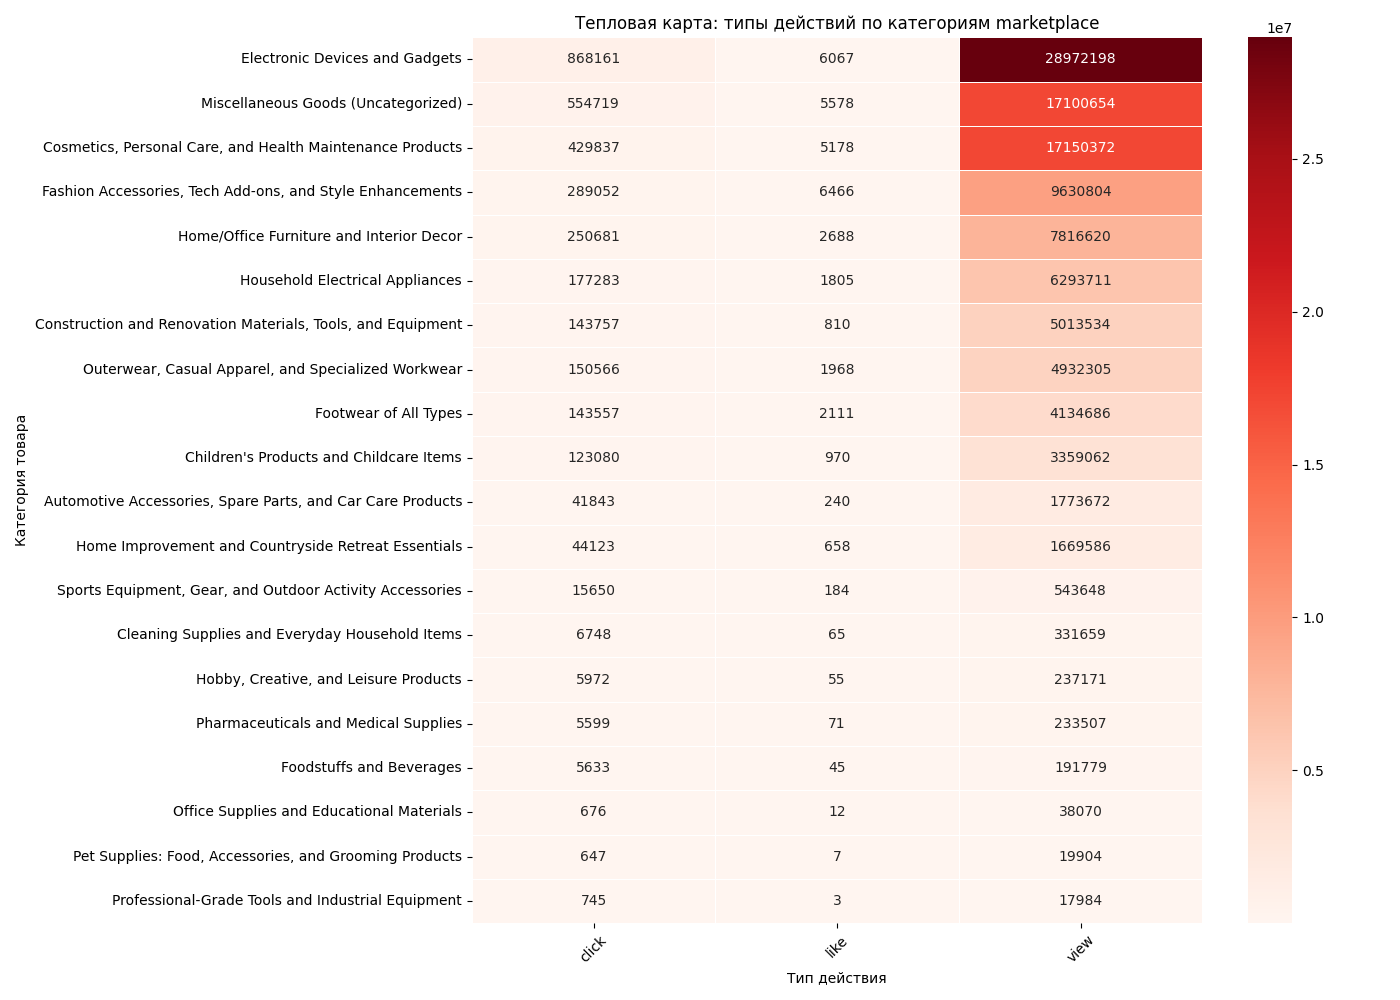

По таблице снова видим, что не смотря на то, что самая активная в плане действий в целом категория - Электроника, конверсия в ключевые действия выше в других категориях.